<a href="https://colab.research.google.com/github/shraddhasaste9676-ai/COFFEEcode/blob/main/prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'train_ground_truth.tsv', 'train_source2.tsv', 'train_source1.tsv', 'sample_data']


In [ ]:
import os

files = [f for f in os.listdir("/content") if f.endswith(".tsv")]

print("TSV files found:")
for f in files:
    print(f)

TSV files found:
train_ground_truth.tsv
train_source2.tsv
train_source1.tsv


In [ ]:
s3 = pd.read_csv("/content/train_source2.tsv", sep="\t")

In [ ]:
import os

print("Files uploaded to Colab:\n")

for file in os.listdir("/content"):
    print(file)

Files uploaded to Colab:

.config
train_ground_truth.tsv
train_source2.tsv
train_source1.tsv
sample_data


In [ ]:
import pandas as pd

s1 = pd.read_csv("/content/train_source1.tsv", sep="\t")
s2 = pd.read_csv("/content/train_source2.tsv", sep="\t")
ground_truth = pd.read_csv("/content/train_ground_truth.tsv", sep="\t")

print("S1 shape:", s1.shape)
print("S2 shape:", s2.shape)
print("Ground Truth shape:", ground_truth.shape)

print("\nS1 columns:")
print(s1.columns.tolist())

print("\nS2 columns:")
print(s2.columns.tolist())

print("\nGround Truth columns:")
print(ground_truth.columns.tolist())

S1 shape: (253300, 4)
S2 shape: (215767, 4)
Ground Truth shape: (528385, 2)

S1 columns:
['entity_id', 'business_name', 'business_address', 'country']

S2 columns:
['entity_id', 'business_name', 'business_address', 'country']

Ground Truth columns:
['source1_entity_id', 'matched_entity_ids']


In [ ]:
display(s1.head())
display(s2.head())
display(ground_truth.head())

,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India


,entity_id,business_name,business_address,country
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India
1,S2-764573417,-- Holloway Peak Inc Seafood,"105 ELM ST, MORGANTON, NC",US
2,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India
3,S2-163963287,Summit Inc,"GREENSBORO, NC, 19 1/2 STARDUST TRAIL",US
4,S2-49942811,Delta Tetlecommunication Inc,"914 PIERPONT AVE, CLEVELAND, OH",US


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."


In [ ]:
print("Number of S1 records:", len(s1))
print("Number of S2 records:", len(s2))
print("Number of Ground Truth records:", len(ground_truth))

Number of S1 records: 253300
Number of S2 records: 215767
Number of Ground Truth records: 528385


In [ ]:
print("S1 columns:", s1.columns.tolist())
print("S2 columns:", s2.columns.tolist())
print("Ground Truth columns:", ground_truth.columns.tolist())

S1 columns: ['entity_id', 'business_name', 'business_address', 'country']
S2 columns: ['entity_id', 'business_name', 'business_address', 'country']
Ground Truth columns: ['source1_entity_id', 'matched_entity_ids']


In [ ]:
display(s1.head())
display(s2.head())
display(ground_truth.head())

,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India


,entity_id,business_name,business_address,country
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India
1,S2-764573417,-- Holloway Peak Inc Seafood,"105 ELM ST, MORGANTON, NC",US
2,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India
3,S2-163963287,Summit Inc,"GREENSBORO, NC, 19 1/2 STARDUST TRAIL",US
4,S2-49942811,Delta Tetlecommunication Inc,"914 PIERPONT AVE, CLEVELAND, OH",US


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."


In [ ]:
print("S1 Country Distribution:")
print(s1["country"].value_counts(dropna=False))

print("\nS2 Country Distribution:")
print(s2["country"].value_counts(dropna=False))

S1 Country Distribution:
country
US       151748
India    101551
NaN           1
Name: count, dtype: int64

S2 Country Distribution:
country
US       129007
India     86759
NaN           1
Name: count, dtype: int64


In [ ]:
print("S1 Missing Values:")
print(s1[["business_name", "business_address", "country"]].isna().sum())

print("\nS2 Missing Values:")
print(s2[["business_name", "business_address", "country"]].isna().sum())

S1 Missing Values:
business_name       1
business_address    1
country             1
dtype: int64

S2 Missing Values:
business_name          0
business_address    7150
country                1
dtype: int64


In [ ]:
s1["name_length"] = s1["business_name"].fillna("").str.len()
s2["name_length"] = s2["business_name"].fillna("").str.len()

In [ ]:
print("S1 Name Length Statistics:")
print(s1["name_length"].describe())

print("\nS2 Name Length Statistics:")
print(s2["name_length"].describe())

S1 Name Length Statistics:
count    253300.000000
mean         24.047627
std           7.732728
min           0.000000
25%          18.000000
50%          24.000000
75%          30.000000
max          81.000000
Name: name_length, dtype: float64

S2 Name Length Statistics:
count    215767.000000
mean         25.077384
std           8.894394
min           2.000000
25%          18.000000
50%          25.000000
75%          31.000000
max         104.000000
Name: name_length, dtype: float64


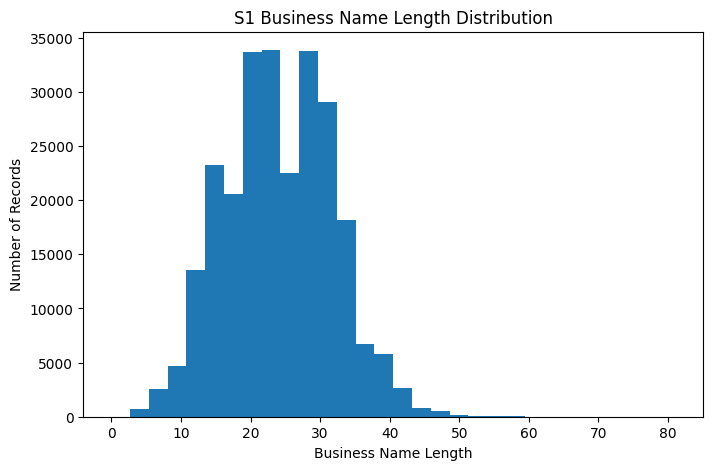

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(s1["name_length"], bins=30)
plt.xlabel("Business Name Length")
plt.ylabel("Number of Records")
plt.title("S1 Business Name Length Distribution")
plt.show()

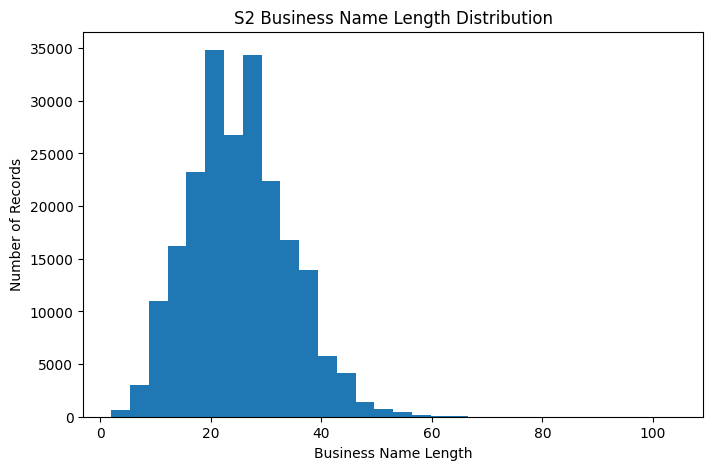

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(s2["name_length"], bins=30)
plt.xlabel("Business Name Length")
plt.ylabel("Number of Records")
plt.title("S2 Business Name Length Distribution")
plt.show()

In [ ]:
s1["address_length"] = s1["business_address"].fillna("").str.len()
s2["address_length"] = s2["business_address"].fillna("").str.len()

print("S1 Address Length:")
print(s1["address_length"].describe())

print("\nS2 Address Length:")
print(s2["address_length"].describe())

S1 Address Length:
count    253300.000000
mean         52.070596
std          25.335672
min           0.000000
25%          33.000000
50%          41.000000
75%          70.000000
max         222.000000
Name: address_length, dtype: float64

S2 Address Length:
count    215767.000000
mean         46.349335
std          24.875762
min           0.000000
25%          30.000000
50%          37.000000
75%          62.000000
max         204.000000
Name: address_length, dtype: float64


In [ ]:
print("Ground Truth columns:")
print(ground_truth.columns.tolist())

display(ground_truth.head(10))

Ground Truth columns:
['source1_entity_id', 'matched_entity_ids']


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."
5,S1-18727616,"S2-755677256,S3-187831601,S3-641489370,S3-4762..."
6,S1-318373630,"S2-660036492,S3-804600254"
7,S1-86989137,"S3-274817120,S3-312496301"
8,S1-29845983,"S2-648035184,S3-588502663"
9,S1-789009573,"S2-383871912,S3-74481402,S3-576451439"


In [ ]:


ground_truth["match_count"] = (
    ground_truth["matched_entity_ids"]
    .fillna("")
    .apply(lambda x: len([i for i in x.split(",") if i.strip()]))
)

display(
    ground_truth[
        ["source1_entity_id", "matched_entity_ids", "match_count"]
    ].head(20)
)

,source1_entity_id,matched_entity_ids,match_count
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129...",5
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843...",4
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467",3
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215",3
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280...",6
5,S1-18727616,"S2-755677256,S3-187831601,S3-641489370,S3-4762...",4
6,S1-318373630,"S2-660036492,S3-804600254",2
7,S1-86989137,"S3-274817120,S3-312496301",2
8,S1-29845983,"S2-648035184,S3-588502663",2
9,S1-789009573,"S2-383871912,S3-74481402,S3-576451439",3


In [ ]:
print("S1 entities with 0 matches:",
      (ground_truth["match_count"] == 0).sum())

print("S1 entities with exactly 1 match:",
      (ground_truth["match_count"] == 1).sum())

print("S1 entities with multiple matches:",
      (ground_truth["match_count"] > 1).sum())

S1 entities with 0 matches: 29647
S1 entities with exactly 1 match: 28566
S1 entities with multiple matches: 470172


In [ ]:
total_s1_in_ground_truth = len(ground_truth)

singletons = (ground_truth["match_count"] == 1).sum()

singleton_percentage = (
    singletons / total_s1_in_ground_truth
) * 100

print("Number of singleton S1 entities:", singletons)
print("Total S1 entities in ground truth:", total_s1_in_ground_truth)
print("Singleton percentage:", round(singleton_percentage, 2), "%")

Number of singleton S1 entities: 28566
Total S1 entities in ground truth: 528385
Singleton percentage: 5.41 %


# New Section

In [3]:
!git clone https://github.com/shraddhasaste9676-ai/COFFEEcode.git

Cloning into 'COFFEEcode'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 10 (delta 1), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), done.
Resolving deltas: 100% (1/1), done.


In [5]:
!ls /content

COFFEEcode  sample_data


In [7]:
%cd /content/COFFEEcode

/content/COFFEEcode


In [8]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [9]:
!ls

code  LICENSE  README.md


In [10]:
!git branch

* main


In [11]:
!git checkout -b gauri-entity

Switched to a new branch 'gauri-entity'


In [12]:
!git branch

* gauri-entity
  main


In [13]:
!ls

code  LICENSE  README.md


In [14]:
!mkdir ML

In [15]:
!ls /content

COFFEEcode  sample_data
